# Bio-SPC Tutorial

**Bio-SPC (Biological Single-cell Pseudotime Cliff-detector)** —  A Python library for detecting cliff points in pseudotime trajectories based on single-cell RNA-seq data.

## Tutorial Goals

1. Understand the core principles of Bio-SPC.
2. Learn how to install and import Bio-SPC.
3. Learn how to prepare input data.
4. Learn how to run the complete pipeline.
5. Learn how to interpret the output results.
6. Learn how to adjust parameters for optimal detection performance.

---
## 1. Installing Bio-SPC

```bash
# Install from PyPI
pip install biospc

# Install from local source code
pip install /path/to/biospc
```

In [7]:
# Import Bio-SPC
from biospc import bio_spc_pipeline

# Import other dependencies
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f'Bio-SPC imported successfully!')
print(f'pandas version: {pd.__version__}')
print(f'numpy version: {np.__version__}')

Bio-SPC imported successfully!
pandas version: 2.3.3
numpy version: 1.26.4


---
## 2. Data Preparation

Bio-SPC requires two types of input data:
1. **Single-cell expression data**: AnnData format (.h5ad file), containing the gene expression matrix.
2. **Time/Pseudotime metadata**: CSV file, containing the time/pseudotime value for each cell.

> **Note**: The default column name for pseudotime is `'Pseudotime'`. If your data uses a different column name,you can specify it using the `time_col` parameter.

In [3]:
# 2.1 Load Single-cell Data
adata = sc.read('./scRNAepithgc.h5ad')
print(f'Number of cells: {adata.shape[0]}')
print(f'Number of genes: {adata.shape[1]}')
print(f'Adata object information:')
adata

细胞数量: 1911
基因数量: 2000
adata 对象信息:


AnnData object with n_obs × n_vars = 1911 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.HB', 'RNA_snn_res.1', 'seurat_clusters', 'celltype'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    varm: 'HARMONY', 'PCs'

In [4]:
# 2.2 Load Pseudotime Metadata
metadata = pd.read_csv('./gc_epith_monocle_pseudo_meta.csv', index_col=0)
print(f'Metadata shape: {metadata.shape}')
print(f'Metadata columns: {metadata.columns.tolist()}')
metadata.head()

元数据形状: (1911, 11)
元数据列: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.HB', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'Size_Factor', 'Pseudotime', 'State']


,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.HB,RNA_snn_res.1,seurat_clusters,celltype,Size_Factor,Pseudotime,State
GSM5101013_Pt1_Normal_0.1,GSM5101013_Pt1_Normal,1036,367,2.702703,0.0,7,7,Epith,0.201953,0.487056,1
GSM5101013_Pt1_Normal_0.9,GSM5101013_Pt1_Normal,757,316,19.815059,0.0,7,7,Epith,0.147566,0.557792,1
GSM5101013_Pt1_Normal_0.11,GSM5101013_Pt1_Normal,4252,1354,1.999059,0.0,7,7,Epith,0.828866,7.767679,6
GSM5101013_Pt1_Normal_0.16,GSM5101013_Pt1_Normal,3384,1135,16.696217,0.0,8,8,Epith,0.659662,7.841879,6
GSM5101013_Pt1_Normal_0.44,GSM5101013_Pt1_Normal,1538,526,1.755527,0.0,7,7,Epith,0.299811,0.475625,1


拟时间范围: [0.000, 10.548]
拟时间均值: 6.452
拟时间中位数: 7.735


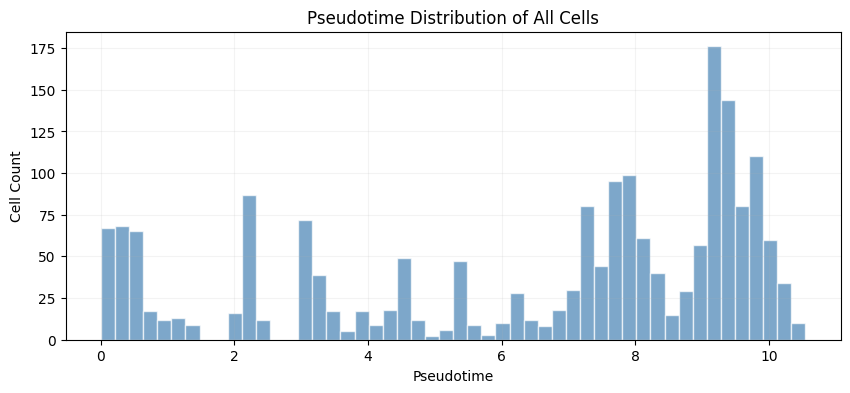

In [5]:
# 2.3 Integrate Pseudotime Information into adata
adata.obs['Pseudotime'] = metadata['Pseudotime']

# Inspect pseudotime distribution
time_vec = adata.obs['Pseudotime'].values
print(f'Pseudotime range:[{time_vec.min():.3f}, {time_vec.max():.3f}]')
print(f'Pseudotime mean: {time_vec.mean():.3f}')
print(f'Pseudotime median: {np.median(time_vec):.3f}')

# Visualize pseudotime distribution
plt.figure(figsize=(10, 4))
plt.hist(time_vec, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
plt.xlabel('Pseudotime')
plt.ylabel('Cell Count')
plt.title('Pseudotime Distribution of All Cells')
plt.grid(alpha=0.15)
plt.show()

---
## 3. Run Bio-SPC Pipeline (Default Parameters)

This is the simplest usage, with all parameters set to default values.

⏳  ResNet1D feature extraction is in progress...
✅ ResNet feature extraction completed
⏳ Scanning trajectory and calculating metrics...

🚀 Bio-SPC Cliff Point Detection Report
Current adaptive weights: 
Bhatt: 0.47 | Wass: 0.37 | IsoForest: 0.16
---------------------------------------------
 Rank        t  Confidence
    1 3.586329    0.663399
    2 8.227461    0.414440


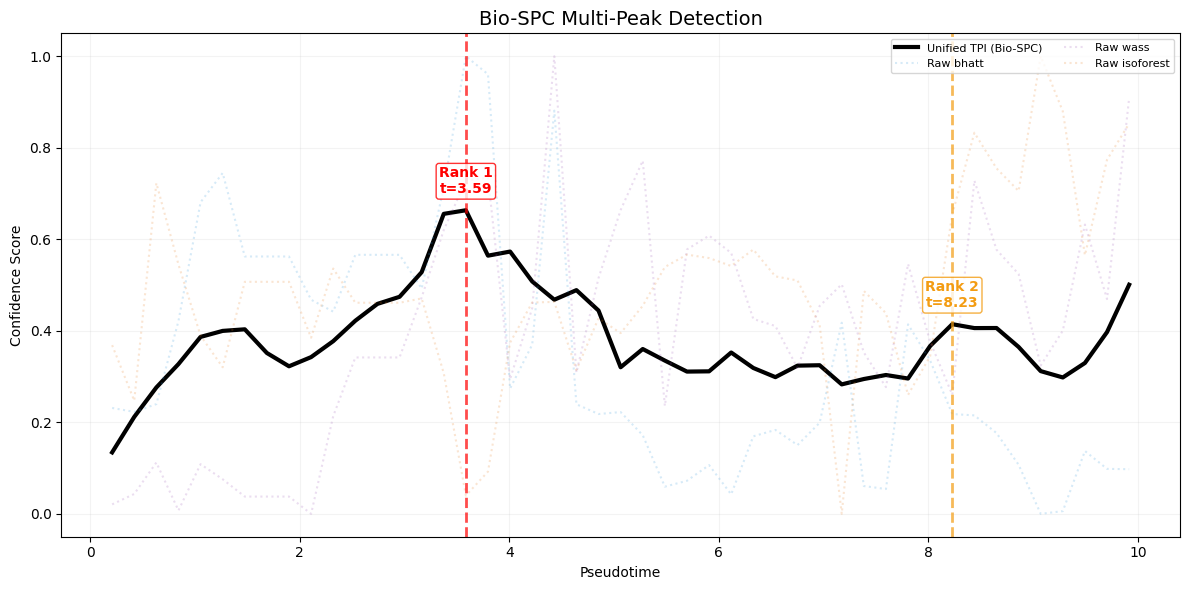

Peak 1 pseudotime: 3.586, number of extracted cells: 78 -> saved to ./bio_spc_output/tipping_peak_1_barcodes.csv
Peak 2 pseudotime: 8.227, number of extracted cells: 215 -> saved to ./bio_spc_output/tipping_peak_2_barcodes.csv

检测到 2 个断崖点


In [6]:
# 3.1 Run with default parameters
peak_report = bio_spc_pipeline(
    adata=adata,
    time_col='Pseudotime',
    random_seed=42,
    do_plot=True,
    save_dir='./bio_spc_output',
)

print(f'\nDetected {len(peak_report)} cliff points')

### Results Interpretation

After running the pipeline, you will see:
1. **Console Output**: Includes adaptive weights and the Rank report.
2. **Visualization**: Curve with cliff points annotated.
3. **CSV File**: A list of cell barcodes corresponding to each cliff point.

**Rank Report Fields Explanation:**
- `Rank`: The importance ranking of the cliff point (1 being the most important).
- `t`: The pseudotime location of the cliff point.
- `Confidence`: The confidence score (the higher the score, the more significant the cliff point).

In [ ]:
# 3.2 View Peak Report
print('=== Cliff Point Detection Report ===')
print(peak_report[['Rank', 't', 'Confidence']].to_string(index=False))

In [ ]:
# 3.3 View the exported cell files
import os
output_dir = './bio_spc_output'
if os.path.exists(output_dir):
    files = [f for f in os.listdir(output_dir) if f.endswith('.csv')]
    print(f'Exported CSV files:')
    for f in sorted(files):
        df = pd.read_csv(os.path.join(output_dir, f))
        print(f'  📄 {f}: {len(df)} cells')

---
## 4. Parameter Details and Optimization
Bio‑SPC provides a comprehensive set of adjustable parameters to enable optimization according to the characteristics of individual datasets.

### 4.1 ResNet Feature Extraction Parameters

| Parameters | Defult | Explanation |
|------|--------|------|
| `out_dim` | `30` | The dimensionality of the reduced features. Increase for more complex data (e.g., 50-100). |
| `hidden_dim` | `128` | The number of neurons in the hidden layer. Increase for more genes (e.g., 256-512). |
| `epochs` | `1000` | The number of training epochs. Increase for large datasets (e.g., 2000), decrease for small datasets (e.g., 500). |
| `lr` | `1e-4` | The learning rate. Typically does not require modification. |

In [ ]:
# Example: Adjust ResNet Parameters
peak_report_v2 = bio_spc_pipeline(
    adata=adata,
    time_col='Pseudotime',
    out_dim=50,          # Increase feature dimension
    hidden_dim=256,      # Increase hidden layer size
    epochs=500,          # Reduce the number of epochs (small dataset)
    lr=1e-4,
    random_seed=42,
    do_plot=False,
    save_dir='./bio_spc_output_v2',
)

if peak_report_v2 is not None:
    print('=== Results after adjusting parameters ===')
    print(peak_report_v2[['Rank', 't', 'Confidence']].to_string(index=False))

### 4.2 Sliding Window Parameters

| Parameter           | Default  | Explanation                                                       |
|---------------------|----------|-------------------------------------------------------------------|
| `step_ratio`        | `0.02`   | The ratio of the step size to the pseudotime span. Smaller values provide finer scans, but increase computational cost. |
| `safe_margin_ratio` | `0.02`   | The ratio of the margin for safe distance. Avoids boundary effects. |
| `min_cells_ratio`   | `0.025`  | The ratio of the minimum number of cells per window (minimum 10). Can be reduced for larger datasets. |

In [ ]:
# Example: Adjusting Window Parameters (Finer Scan)
peak_report_v3 = bio_spc_pipeline(
    adata=adata,
    time_col='Pseudotime',
    step_ratio=0.01,          # Halve the step size for finer scanning
    safe_margin_ratio=0.01,   # Reduce the safe margin distance
    min_cells_ratio=0.02,     # Lower the minimum cell count ratio
    random_seed=42,
    do_plot=False,
    save_dir='./bio_spc_output_v3',
)

if peak_report_v3 is not None:
    print('=== Results from Finer Scan ===')
    print(peak_report_v3[['Rank', 't', 'Confidence']].to_string(index=False))

### 4.3 Smoothing and Peak Detection Parameters

| Parameter        | Default  | Explanation                                                       |
|------------------|----------|-------------------------------------------------------------------|
| `smooth_window`  | `7`      | The window length for Savitzky-Golay filtering (must be odd). Larger values result in smoother curves. |
| `polyorder`      | `2`      | The polynomial order. Must be less than `smooth_window`.          |
| `prominence`     | `0.1`    | The minimum prominence of peaks. Larger values result in stricter criteria, detecting fewer peaks. |
| `distance`       | `5`      | The minimum distance between peaks (in number of points). Larger values lead to sparser peaks. |

In [ ]:
# Example: Adjusting Peak Detection Parameters (Stricter Detection)
peak_report_v4 = bio_spc_pipeline(
    adata=adata,
    time_col='Pseudotime',
    smooth_window=11,         # Larger smoothing window
    polyorder=3,              # Higher polynomial order
    prominence=0.15,          # Higher prominence threshold
    distance=10,              # Larger distance between peaks
    random_seed=42,
    do_plot=False,
    save_dir='./bio_spc_output_v4',
)

if peak_report_v4 is not None:
    print('=== Strict Peak Detection Results ===')
    print(peak_report_v4[['Rank', 't', 'Confidence']].to_string(index=False))

### 4.4 Cell Extraction Parameters

| Parameter       | Default  | Explanation                                                       |
|-----------------|----------|-------------------------------------------------------------------|
| `extract_ratio` | `0.04`   | The ratio of the extraction window radius to the pseudotime span. Larger values result in extracting more cells. |
| `save_dir`      | `'./'`    | The directory path for saving the CSV file.                       |

In [8]:
# Example: Adjusting Cell Extraction Parameters (Extracting More Cells)
peak_report_v5 = bio_spc_pipeline(
    adata=adata,
    time_col='Pseudotime',
    extract_ratio=0.06,       # Expand the extraction window
    save_dir='./bio_spc_output_v5',
    random_seed=42,
    do_plot=False,
)

if peak_report_v5 is not None:
    print('=== Number of Cells After Expanding Extraction Window ===')
    for f in sorted(os.listdir('./bio_spc_output_v5')):
        if f.endswith('.csv'):
            df = pd.read_csv(f'./bio_spc_output_v5/{f}')
            print(f'  {f}: {len(df)} cells')

⏳  ResNet1D feature extraction is in progress...
✅ ResNet feature extraction completed
⏳ Scanning trajectory and calculating metrics...

🚀 Bio-SPC Cliff Point Detection Report
Current adaptive weights: 
Bhatt: 0.47 | Wass: 0.37 | IsoForest: 0.16
---------------------------------------------
 Rank        t  Confidence
    1 3.586329    0.663399
    2 8.227461    0.414440
Peak 1 pseudotime: 3.586, number of extracted cells: 159 -> saved to ./bio_spc_output_v5/tipping_peak_1_barcodes.csv
Peak 2 pseudotime: 8.227, number of extracted cells: 339 -> saved to ./bio_spc_output_v5/tipping_peak_2_barcodes.csv
=== Number of Cells After Expanding Extraction Window ===
  tipping_peak_1_barcodes.csv: 159 cells
  tipping_peak_2_barcodes.csv: 339 cells


### 4.5 Visualization Parameters

| Parameter   | Default                            | Explanation                                                       |
|-------------|------------------------------------|-------------------------------------------------------------------|
| `colors`    | `['#3498db', '#9b59b6', '#e67e22']` | Colors for the curves of the original metrics.                    |
| `alpha`     | `0.2`                              | Transparency of the original metric curves.                       |
| `figsize`   | `(12, 6)`                           | The size of the figure.                                           |
| `do_plot`   | `True`                             | Whether to display the visualization plot.                         |

⏳  ResNet1D feature extraction is in progress...
✅ ResNet feature extraction completed
⏳ Scanning trajectory and calculating metrics...

🚀 Bio-SPC Cliff Point Detection Report
Current adaptive weights: 
Bhatt: 0.47 | Wass: 0.37 | IsoForest: 0.16
---------------------------------------------
 Rank        t  Confidence
    1 3.586329    0.663399
    2 8.227461    0.414440


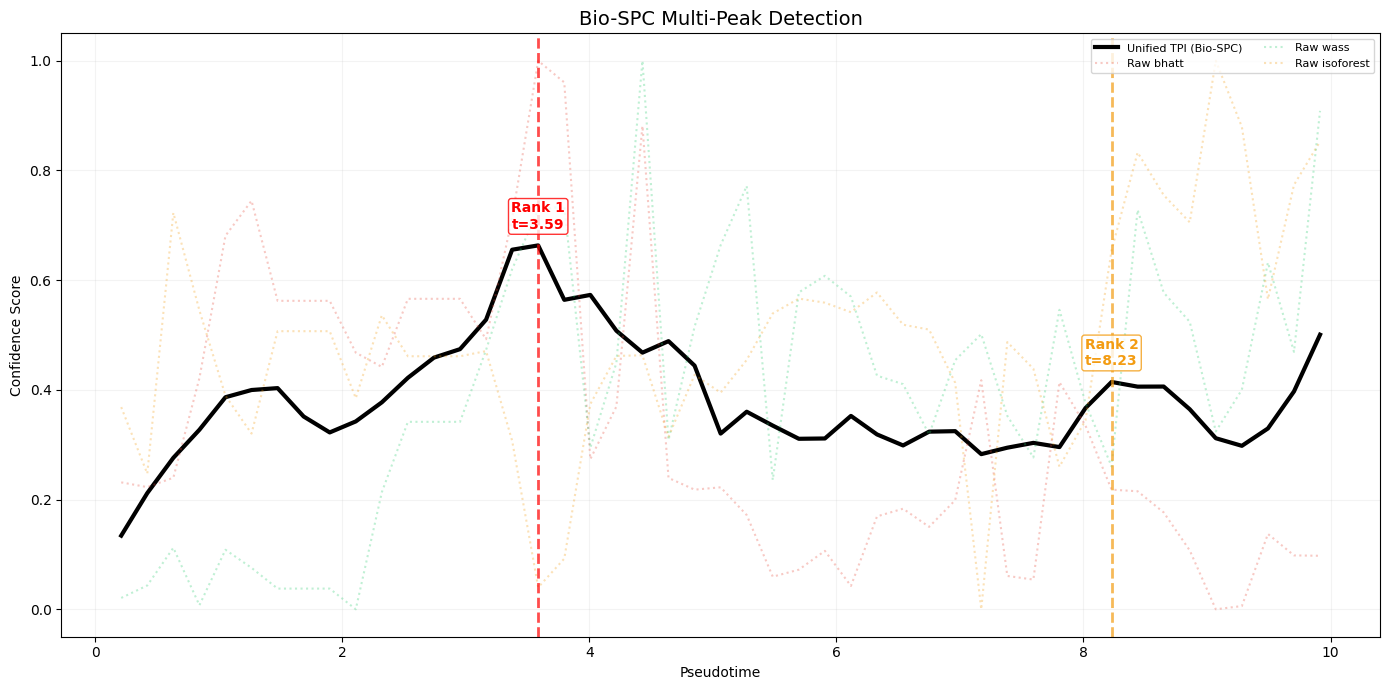

Peak 1 pseudotime: 3.586, number of extracted cells: 78 -> saved to ./bio_spc_output_v6/tipping_peak_1_barcodes.csv
Peak 2 pseudotime: 8.227, number of extracted cells: 215 -> saved to ./bio_spc_output_v6/tipping_peak_2_barcodes.csv


In [9]:
# Example: Customizing Visualization Style
peak_report_v6 = bio_spc_pipeline(
    adata=adata,
    time_col='Pseudotime',
    random_seed=42,
    do_plot=True,
    colors=['#e74c3c', '#2ecc71', '#f39c12'],  # Custom colors
    alpha=0.3,                                   # Increase transparency
    figsize=(14, 7),                             # Larger figure size
    save_dir='./bio_spc_output_v6',
)

---
## 5. Results Interpretation and Downstream Analysis

### 5.1 Understanding the TPI Curve

The CPI (Cliff Point Index) curve is the core output of Bio-SPC:
- **Black solid line**: The combined CPI curve, representing the cliff signal after integrating three metrics.
- **Colored dashed lines**: The normalized scores of the three original metrics (Bhattacharyya, Wasserstein, IsolationForest).
- **Red dashed line**: Rank 1 cliff point (the most important turning point).
- **Orange dashed line**: Other cliff points.

The higher the peak of the curve, the greater the likelihood that a state transition occurs at that position.

In [10]:
# 5.2 View the Exported Cells
peak_1_cells = pd.read_csv('./bio_spc_output/tipping_peak_1_barcodes.csv')
print(f'Cell list for Peak 1 (Rank 1) (first 10 cells):')
print(peak_1_cells.head(10))
print(f'\n... Total of {len(peak_1_cells)} cells')

Cell list for Peak 1 (Rank 1) (first 10 cells):
                            Barcode    Tipping_Name  Tipping_Peak
0       GSM5101013_Pt1_Normal_0.152  tipping_peak_1      3.586329
1       GSM5101013_Pt1_Normal_0.848  tipping_peak_1      3.586329
2   GSM5101014_Pt1_Superficial_0.15  tipping_peak_1      3.586329
3   GSM5101014_Pt1_Superficial_0.34  tipping_peak_1      3.586329
4   GSM5101014_Pt1_Superficial_0.71  tipping_peak_1      3.586329
5  GSM5101014_Pt1_Superficial_0.199  tipping_peak_1      3.586329
6  GSM5101014_Pt1_Superficial_0.201  tipping_peak_1      3.586329
7  GSM5101014_Pt1_Superficial_0.324  tipping_peak_1      3.586329
8  GSM5101014_Pt1_Superficial_0.379  tipping_peak_1      3.586329
9  GSM5101014_Pt1_Superficial_0.450  tipping_peak_1      3.586329

... Total of 78 cells


In [11]:
# 5.3 Downstream Analysis Example: Check Sample Sources of Cliff Point Cells
peak_1_barcodes = set(peak_1_cells['Barcode'].values)
all_barcodes = set(adata.obs_names)

# Extract metadata for cliff point cells
tipping_obs = adata.obs.loc[adata.obs_names.isin(peak_1_barcodes)]
print(f'Source distribution of cliff point cells:')
print(tipping_obs.index.to_series().str.extract(r'(Pt\d+)')[0].value_counts())

Source distribution of cliff point cells:
0
Pt1    37
Pt2    13
Pt4    11
Pt5    10
Pt3     7
Name: count, dtype: int64


---
## 6. Complete Workflow Example

Below is a complete example from data loading to result export, suitable for direct copying into your project.

In [ ]:
# ==========================================
# Bio-SPC Complete Workflow
# ==========================================

import scanpy as sc
import pandas as pd
from biospc import bio_spc_pipeline

# 1. Load Data
print('Step 1: Loading data...')
adata = sc.read('./data/scRNAepithgc.h5ad')
metadata = pd.read_csv('./data/gc_epith_monocle_pseudo_meta.csv', index_col=0)
adata.obs['Pseudotime'] = metadata['Pseudotime']
print(f'  {adata.shape[0]} cells, {adata.shape[1]} genes')

# 2. Run Pipeline
print('Step 2: Running Bio-SPC Pipeline...')
peak_report = bio_spc_pipeline(
    adata=adata,
    time_col='Pseudotime',
    out_dim=30,
    hidden_dim=128,
    epochs=1000,
    lr=1e-4,
    step_ratio=0.02,
    safe_margin_ratio=0.02,
    min_cells_ratio=0.025,
    smooth_window=7,
    polyorder=2,
    prominence=0.1,
    distance=5,
    extract_ratio=0.04,
    save_dir='./my_biospc_results',
    random_seed=42,
    do_plot=True,
)

# 3. Output Results Summary
if peak_report is not None:
    print(f'\nStep 3: Detection completed!')
    print(f'  {len(peak_report)} cliff points detected')
    print(f'  Most important cliff point (Rank 1): t={peak_report.iloc[0]["t"]:.3f}')
    print(f'  Results saved to ./my_biospc_results/')
else:
    print('\nStep 3: No significant cliff points detected.')

---
## 7. Frequently Asked Questions (FAQ)

### Q1: Why are no cliff points detected in my data?
- Check if the pseudotime column name is correct (the `time_col` parameter).
- Try lowering the `prominence` value (e.g., 0.05).
- Ensure there are enough cells in the data (recommended > 500).

### Q2: How can I ensure reproducibility of the results?
- Set the `random_seed` parameter to a fixed value (e.g., 42).
- With the same machine and parameters, the results will be fully consistent.

### Q3: What should I do if too many/few cliff points are detected?
- Too many: Increase the `prominence` and `distance`.
- Too few: Decrease the `prominence` and `distance`.

### Q4: How to choose an appropriate `out_dim`?
- Generally, 20-50 is sufficient.
- For datasets with > 5000 genes, you can increase the value.
- For datasets with high noise, you can decrease the value.

### Q5: What should I do if the running time is too long?
- Reduce the `epochs` (e.g., 500).
- Increase the `step_ratio` (e.g., 0.03).
- Decrease the `hidden_dim` (e.g., 64).

---
## 8. Clean Up Temporary Files

In [12]:
# Clean up temporary files generated by this tutorial (optional)
import os
import shutil

temp_dirs = [
    './bio_spc_output',
    './bio_spc_output_v2',
    './bio_spc_output_v3',
    './bio_spc_output_v4',
    './bio_spc_output_v5',
    './bio_spc_output_v6',
    './my_biospc_results',
]

for d in temp_dirs:
    if os.path.exists(d):
        shutil.rmtree(d)
        print(f'Deleted: {d}')

print('\nCleanup completed!')

Deleted: ./bio_spc_output
Deleted: ./bio_spc_output_v5
Deleted: ./bio_spc_output_v6

Cleanup completed!


---
## Summary

Through this tutorial, you have learned how to:

1. ✅ Install and import Bio-SPC
2. ✅ Prepare input data (AnnData + pseudotime metadata)
3. ✅ Run the pipeline with default parameters
4. ✅ Adjust various parameters to optimize detection results
5. ✅ Interpret the output results (Rank report, CSV files, visualizations)
6. ✅ Extract cliff point cells for downstream analysis

For more information, please visit: [Bio-SPC GitHub Repository](https://github.com/your-username/biospc)